# Manufacturing Machine Failure Analysis


## 1. Data Understanding & Overview

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats


df = pd.read_csv('6_manufacturing_failure.csv')
display(df.head(20))
print("\n--- Data Shape ---")
print(df.shape)
print("\n--- Summary Statistics ---")
display(df.describe())

,machine_id,machine_type,manufacturer,model_year,machine_age_years,warranty_status,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,...,corrosion_level,oil_quality_index,bearing_temperature_c,current_amps,voltage_volts,torque_nm,startup_cycles_per_day,emergency_stops_count,overloads_count_last_month,failure_next_30days
0,MCH_00000001,Conveyor,Siemens,2018,6,Expired,13,66,3.60,75.2,...,Minor,62.0,60.5,46.15,431.8,205.19,5,1,2,No
1,MCH_00000002,Compressor,Siemens,2016,8,Expired,14,79,2.98,95.3,...,NaN,65.0,48.3,59.47,436.3,226.17,4,0,2,No
2,MCH_00000003,Motor,Other,2014,10,Expired,23,46,0.55,65.6,...,Minor,70.0,54.6,48.11,442.4,233.35,2,0,0,No
3,MCH_00000004,Motor,ABB,2009,15,Expired,8,91,7.76,51.5,...,NaN,88.0,59.3,49.81,453.8,199.22,9,0,2,Yes
4,MCH_00000005,Valve,Siemens,2009,15,Expired,21,86,0.79,64.3,...,Severe,60.0,72.4,62.36,437.7,208.66,3,1,3,Yes
5,MCH_00000006,Motor,Siemens,2022,2,Under Warranty,21,95,3.06,76.6,...,Minor,61.0,58.9,69.04,419.0,247.34,7,0,0,No
6,MCH_00000007,Generator,Schneider,2017,7,Expired,14,62,3.13,90.1,...,NaN,100.0,40.9,57.16,435.6,167.80,3,0,0,Yes
7,MCH_00000008,Compressor,Mitsubishi,2021,3,Under Warranty,19,70,3.49,38.9,...,NaN,NaN,53.0,79.37,463.0,327.63,4,1,2,No
8,MCH_00000009,Pump,ABB,2012,12,Expired,16,91,1.86,40.2,...,NaN,59.0,53.3,63.00,449.0,192.10,3,0,0,No
9,MCH_00000010,Generator,Schneider,2015,9,Expired,12,30,0.00,86.2,...,Moderate,66.0,58.2,62.98,434.4,156.51,4,0,2,No



--- Data Shape ---
(15000, 34)

--- Summary Statistics ---


,model_year,machine_age_years,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,pressure_bar,rpm,power_consumption_kw,noise_level_db,...,ambient_temperature_c,humidity_percentage,oil_quality_index,bearing_temperature_c,current_amps,voltage_volts,torque_nm,startup_cycles_per_day,emergency_stops_count,overloads_count_last_month
count,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000,14400.000000,15000.000000,15000.000000,15000.000000
mean,2014.037533,9.962467,15.438733,74.300867,2.495436,64.994827,8.000321,1800.940800,49.778068,74.502600,...,25.065053,59.561800,74.201597,55.213100,50.010664,440.185293,200.188817,3.056067,0.497067,1.004400
std,5.451187,5.451187,3.925142,14.387046,2.505247,14.977593,1.994459,401.625426,50.151818,9.889765,...,8.033842,14.772932,14.373969,12.018664,14.980027,20.070868,49.875274,1.660534,0.709759,1.009446
min,2005.000000,1.000000,4.000000,30.000000,0.000000,8.400000,0.360000,500.000000,0.000000,50.000000,...,-5.800000,20.000000,21.000000,1.700000,-12.250000,359.600000,2.610000,1.000000,0.000000,0.000000
25%,2009.000000,5.000000,13.000000,65.000000,0.690000,54.900000,6.640000,1525.000000,14.240000,68.000000,...,19.700000,49.000000,64.000000,47.200000,39.740000,426.600000,166.720000,2.000000,0.000000,0.000000
50%,2014.000000,10.000000,15.000000,75.000000,1.710000,64.900000,8.000000,1797.000000,33.905000,75.000000,...,25.000000,59.000000,74.000000,55.200000,49.930000,440.100000,200.050000,3.000000,0.000000,1.000000
75%,2019.000000,15.000000,18.000000,85.000000,3.500000,75.000000,9.350000,2076.000000,69.165000,81.000000,...,30.500000,70.000000,85.000000,63.200000,60.085000,454.200000,233.450000,4.000000,1.000000,2.000000
max,2023.000000,19.000000,24.000000,100.000000,23.140000,134.100000,16.060000,3600.000000,521.530000,110.000000,...,63.600000,95.000000,100.000000,103.400000,105.140000,515.300000,385.890000,14.000000,5.000000,7.000000


## 2. Exploratory Data Analysis (EDA)

--- Missing Values ---
vibration_level_mm_s     600
corrosion_level         7504
oil_quality_index        600
torque_nm                600
dtype: int64


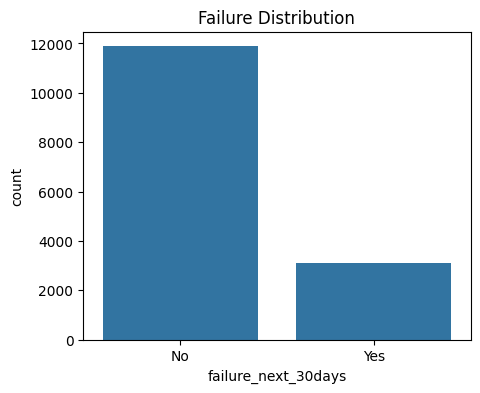

Failure Distribution (%):
failure_next_30days
No     79.246667
Yes    20.753333
Name: proportion, dtype: float64


In [2]:

print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])


plt.figure(figsize=(5, 4))
sns.countplot(x='failure_next_30days', data=df )
plt.title('Failure Distribution')
plt.show()

print("Failure Distribution (%):")
print(df['failure_next_30days'].value_counts(normalize=True) * 100 )

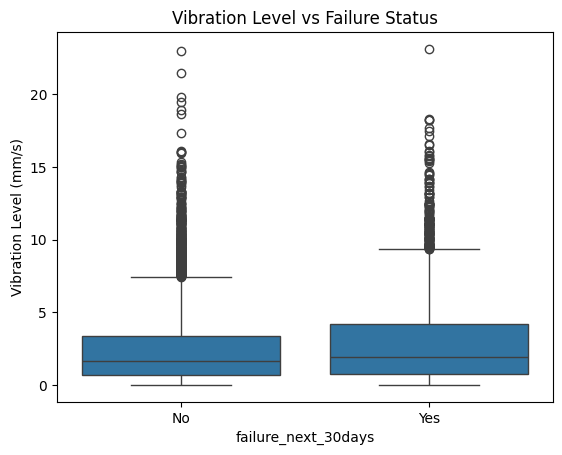

In [3]:

sns.boxplot(data=df, x='failure_next_30days', y='vibration_level_mm_s')

plt.title('Vibration Level vs Failure Status')
plt.ylabel('Vibration Level (mm/s)')
plt.show()


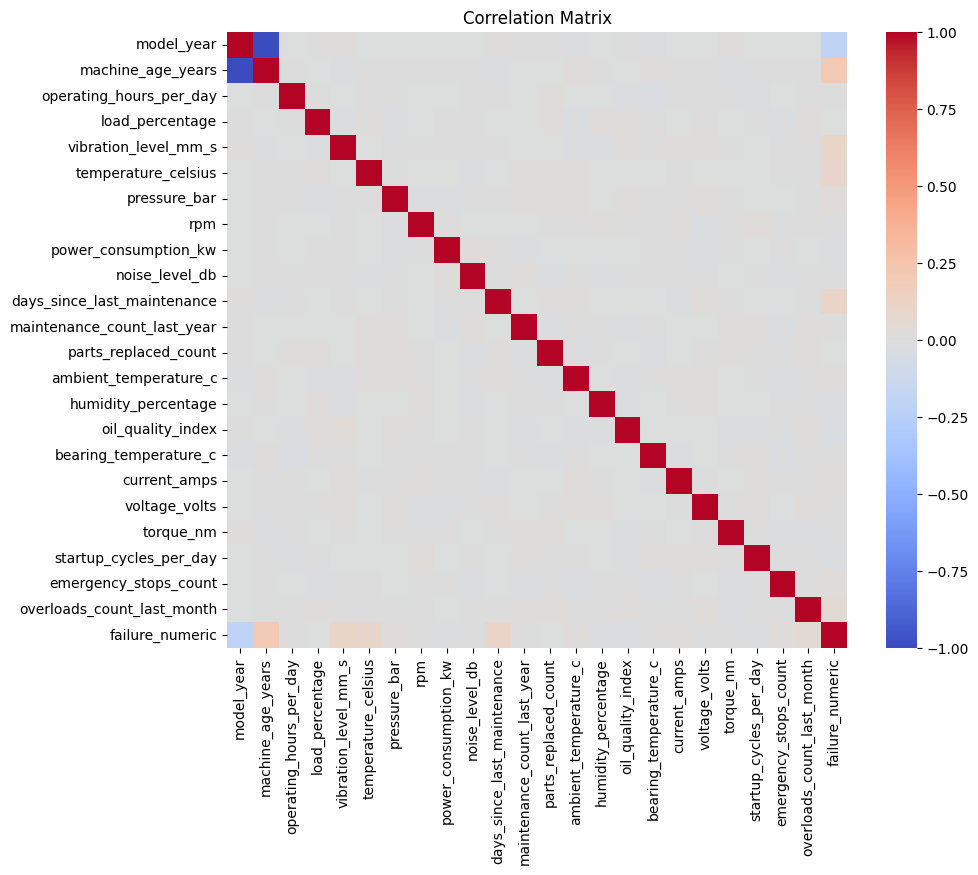

In [4]:

df['failure_numeric'] = df['failure_next_30days'].apply(lambda x: 1 if x == 'Yes' else 0)


plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

df.drop('failure_numeric', axis=1, inplace=True)

## 3. Feature Engineering & Categorical Encoding

In [12]:

warranty_map = {'Under Warranty': 1, 'Expired': 0}
lub_map = {'Excellent': 5, 'Good': 4, 'Fair': 3, 'Poor': 2}
align_map = {'Aligned': 3, 'Slightly Off': 2, 'Misaligned': 1}
dust_map = {'Low': 1, 'Medium': 2, 'High': 3}
corrosion_map = {'None': 1, 'Minor': 2, 'Moderate': 3, 'Severe': 4}
tech_map = {'Expert': 4, 'Senior': 3, 'Intermediate': 2, 'Junior': 1}

df['warranty_num'] = df['warranty_status'].map(warranty_map)
df['lub_num'] = df['lubrication_quality'].map(lub_map)
df['align_num'] = df['alignment_status'].map(align_map)
df['dust_num'] = df['dust_exposure_level'].map(dust_map)
df['corrosion_num'] = df['corrosion_level'].map(corrosion_map)
df['tech_num'] = df['technician_skill_level'].map(tech_map)



cols_to_fill = ['warranty_num', 'lub_num', 'align_num', 'dust_num', 'corrosion_num', 'tech_num','vibration_level_mm_s', 'oil_quality_index', 'torque_nm']

for col in cols_to_fill:
    grouped_median = df.groupby('machine_type')[col].transform('median')
    df[col] = df[col].fillna(grouped_median)




if df['failure_next_30days'].dtype == 'object' or df['failure_next_30days'].dtype == 'str':
    df['failure_next_30days'] = df['failure_next_30days'].map({'Yes': 1, 'No': 0})



if 'bearing_temperature_c' in df.columns and 'ambient_temperature_c' in df.columns:
    df['temp_diff_c'] = df['bearing_temperature_c'] - df['ambient_temperature_c']



categorical_cols = df.select_dtypes(include=['object']).columns
cols_to_encode = [c for c in categorical_cols if c != 'machine_id']



dv = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print("Final Dataset Shape after One-Hot Encoding:", df.shape)
display(dv.head())

display(df)

print(df.columns)



Final Dataset Shape after One-Hot Encoding: (15000, 42)


C:\Users\GokulkannaML\AppData\Local\Temp\ipykernel_12252\607470591.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,machine_id,model_year,machine_age_years,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,pressure_bar,rpm,power_consumption_kw,...,technician_skill_level_Senior,lubrication_quality_Fair,lubrication_quality_Good,lubrication_quality_Poor,alignment_status_Misaligned,alignment_status_Slightly Off,dust_exposure_level_Low,dust_exposure_level_Medium,corrosion_level_Moderate,corrosion_level_Severe
0,MCH_00000001,2018,6,13,66,3.60,75.2,8.58,1377,28.28,...,False,True,False,False,False,False,True,False,False,False
1,MCH_00000002,2016,8,14,79,2.98,95.3,9.24,1784,5.26,...,False,False,False,False,False,True,True,False,False,False
2,MCH_00000003,2014,10,23,46,0.55,65.6,12.17,1274,45.01,...,True,True,False,False,False,False,False,False,False,False
3,MCH_00000004,2009,15,8,91,7.76,51.5,7.81,2162,19.64,...,False,False,False,False,False,True,False,True,False,False
4,MCH_00000005,2009,15,21,86,0.79,64.3,7.70,1904,2.22,...,True,False,True,False,False,False,False,True,False,True


,machine_id,machine_type,manufacturer,model_year,machine_age_years,warranty_status,operating_hours_per_day,load_percentage,vibration_level_mm_s,temperature_celsius,...,overloads_count_last_month,failure_next_30days,warranty_num,lub_num,align_num,dust_num,corrosion_num,tech_num,temp_diff_c,is_old
0,MCH_00000001,Conveyor,Siemens,2018,6,Expired,13,66,3.60,75.2,...,2,0,0,3,3,1,2.0,1,40.3,False
1,MCH_00000002,Compressor,Siemens,2016,8,Expired,14,79,2.98,95.3,...,2,0,0,5,2,1,2.0,1,24.3,False
2,MCH_00000003,Motor,Other,2014,10,Expired,23,46,0.55,65.6,...,0,0,0,3,3,3,2.0,3,25.5,False
3,MCH_00000004,Motor,ABB,2009,15,Expired,8,91,7.76,51.5,...,2,1,0,5,2,2,2.0,2,34.5,True
4,MCH_00000005,Valve,Siemens,2009,15,Expired,21,86,0.79,64.3,...,3,1,0,4,3,2,4.0,3,44.9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,MCH_00014996,Conveyor,Other,2021,3,Under Warranty,12,100,2.88,61.7,...,2,0,1,4,3,2,2.0,1,12.7,False
14996,MCH_00014997,Motor,Siemens,2020,4,Expired,15,52,4.99,100.7,...,0,0,0,3,3,1,2.0,3,39.0,False
14997,MCH_00014998,Conveyor,ABB,2011,13,Expired,12,95,1.71,76.0,...,0,1,0,2,3,1,2.0,1,-2.6,True
14998,MCH_00014999,Motor,ABB,2020,4,Expired,15,87,1.89,38.8,...,1,0,0,3,3,2,3.0,3,17.4,False


Index(['machine_id', 'machine_type', 'manufacturer', 'model_year',
       'machine_age_years', 'warranty_status', 'operating_hours_per_day',
       'load_percentage', 'vibration_level_mm_s', 'temperature_celsius',
       'pressure_bar', 'rpm', 'power_consumption_kw', 'noise_level_db',
       'days_since_last_maintenance', 'maintenance_count_last_year',
       'last_maintenance_type', 'technician_skill_level',
       'parts_replaced_count', 'lubrication_quality', 'alignment_status',
       'ambient_temperature_c', 'humidity_percentage', 'dust_exposure_level',
       'corrosion_level', 'oil_quality_index', 'bearing_temperature_c',
       'current_amps', 'voltage_volts', 'torque_nm', 'startup_cycles_per_day',
       'emergency_stops_count', 'overloads_count_last_month',
       'failure_next_30days', 'warranty_num', 'lub_num', 'align_num',
       'dust_num', 'corrosion_num', 'tech_num', 'temp_diff_c', 'is_old'],
      dtype='str')


In [13]:
print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing>0])

--- Missing Values ---
corrosion_level    7504
dtype: int64


## 4. Hypothesis Validation


### Hypothesis 1: Higher vibration leads to higher failure rates


Average Vibration Level:
 failure_next_30days
0    2.336029
1    2.952747
Name: vibration_level_mm_s, dtype: float64


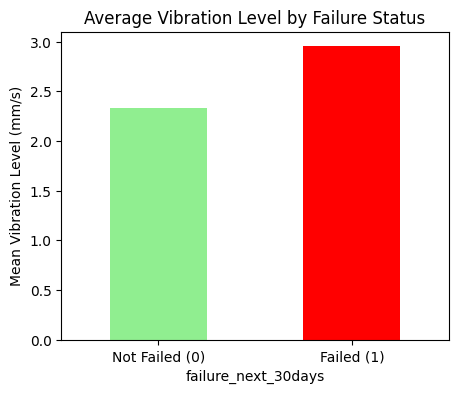

Conclusion: Failed machines have a notably higher average vibration level. The hypothesis is supported.
H1 - Vibration: t=12.52, p=0.0000 Significant


In [7]:
vibration_aggs = df.groupby('failure_next_30days')['vibration_level_mm_s'].mean()
print("Average Vibration Level:\n", vibration_aggs)


vibration_aggs.plot(kind='bar', color=['lightgreen', 'red'], figsize=(5,4))
plt.title('Average Vibration Level by Failure Status')
plt.xticks(ticks=[0, 1], labels=['Not Failed (0)', 'Failed (1)'], rotation=0)
plt.ylabel('Mean Vibration Level (mm/s)')
plt.show()


if vibration_aggs.iloc[1] > vibration_aggs.iloc[0]:
    print("Conclusion: Failed machines have a notably higher average vibration level. The hypothesis is supported.")
else:
    print("Conclusion: Failed machines do not have a higher average vibration. The hypothesis is NOT supported.")

fail_vib = df[df['failure_next_30days']==1]['vibration_level_mm_s']
no_fail_vib = df[df['failure_next_30days']==0]['vibration_level_mm_s']
t_stat1, p_val1 = stats.ttest_ind(fail_vib, no_fail_vib)
print(f'H1 - Vibration: t={t_stat1:.2f}, p={p_val1:.4f} {"Significant" if p_val1<0.05 else "Not significant"}')


### Hypothesis 2: Older machines (Age > 10 years) fail more often
**Logic:** Create a dummy grouping for 'is_old' machines (older than 10 years) and compare the % of failure between Old vs. New machines using `groupby().mean()`.

int64
int64
0        0
1        0
2        0
3        1
4        1
        ..
14995    0
14996    0
14997    1
14998    0
14999    0
Name: failure_next_30days, Length: 15000, dtype: int64
Failure Rate by Age Group (%):
 is_old
False    11.754408
True     31.029559
Name: failure_next_30days, dtype: float64


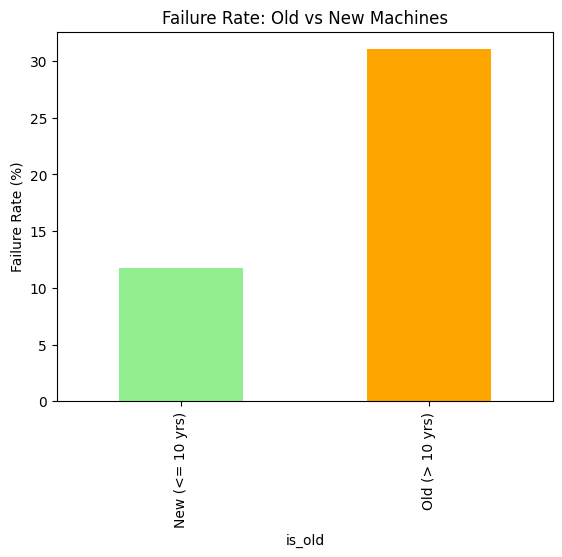


Conclusion: Older machines have a higher failure rate. The hypothesis is supported.
H2 - OlderMachines: t=29.89, p=0.0000  Reject the null hypothesis -> Significant difference exists


In [14]:
print(df['machine_age_years'].dtype)
print(df['failure_next_30days'].dtype)
print(df['failure_next_30days'])
df['is_old'] = df['machine_age_years']>10


failure_rate_by_age = df.groupby('is_old')['failure_next_30days'].mean() * 100
print("Failure Rate by Age Group (%):\n", failure_rate_by_age)

failure_rate_by_age.plot(kind='bar', color=['lightgreen', 'orange'])
plt.title('Failure Rate: Old vs New Machines')
plt.xticks(ticks=[0, 1], labels=['New (<= 10 yrs)', 'Old (> 10 yrs)'])
plt.ylabel('Failure Rate (%)')
plt.show()

if failure_rate_by_age.iloc[1] > failure_rate_by_age.iloc[0]:
    print("\nConclusion: Older machines have a higher failure rate. The hypothesis is supported.")
else:
    print("\nConclusion: Older machines do not fail more often. The hypothesis is NOT supported.")

old_machines= df[df['failure_next_30days']==1]['is_old']
young_machines = df[df['failure_next_30days']==0]['is_old']
t_stat1, p_val1 = stats.ttest_ind(old_machines, young_machines)
print(f'H2 - OlderMachines: t={t_stat1:.2f}, p={p_val1:.4f} {" Reject the null hypothesis -> Significant difference exists" if p_val1<0.05 else " Fail to reject the null hypothesis -> No significant difference"}')

### Hypothesis 3 : Older machines with poor maintenance are more likely to fail

In [9]:
new_df = df[(df["maintenance_count_last_year"]< df["maintenance_count_last_year"].mean()) | (df["is_old"])]
count = new_df[new_df["failure_next_30days"]==1]["failure_next_30days"].count()
print("Hypothesis failure next 30 days count")
print(count)
print("original dataset failure next 30 days")
og_count =df[df["failure_next_30days"]==1]["failure_next_30days"].count()
print(og_count)

print("accuracy of this hypothesis")
print(count*100/og_count)

Hypothesis failure next 30 days count
2747
original dataset failure next 30 days
3113
accuracy of this hypothesis
88.24285255380661


## Hypothesis 4 : Machines which are old or with poor manteinance or high vibrations are more likely to fail

In [10]:
new_df = df[(df["maintenance_count_last_year"]< df["maintenance_count_last_year"].mean()) | (df["is_old"]) | (df["vibration_level_mm_s"]> df["vibration_level_mm_s"].mean())]
count = new_df[new_df["failure_next_30days"]==1]["failure_next_30days"].count()
print("Hypothesis failure next 30 days count")
print(count)
print("original dataset failure next 30 days")
og_count =df[df["failure_next_30days"]==1]["failure_next_30days"].count()
print(og_count)

print("accuracy of this hypothesis")
print(count*100/og_count)

Hypothesis failure next 30 days count
2923
original dataset failure next 30 days
3113
accuracy of this hypothesis
93.89656280115643


### Hypothesis 5: Higher Operating Load or Hours leads to higher failure rates

In [11]:
new_df = df[(df['load_percentage'] > df['load_percentage'].mean()) | (df['operating_hours_per_day'] > df['operating_hours_per_day'].mean())]
count = new_df[new_df['failure_next_30days']==1]['failure_next_30days'].count()
print('Hypothesis failure next 30 days count')
print(count)
print('original dataset failure next 30 days')
og_count = df[df['failure_next_30days']==1]['failure_next_30days'].count()
print(og_count)

print('accuracy of this hypothesis')
print(count*100/og_count)

Hypothesis failure next 30 days count
2312
original dataset failure next 30 days
3113
accuracy of this hypothesis
74.26919370382268
